# Price-Intent Backtest

Test a dynamic long/short trade plan for multiple Yahoo Finance tickers. Set the ticker list, rolling-price rules, sizing, costs, and risk limits in **Block 1**, then run all cells.

The notebook downloads daily OHLCV data, caches it under `cache/price_history/`, checks current index membership using the same cached constituent workflow as `03_index_search.ipynb`, and compares the strategy with buy-and-hold and the selected index.

> This is a daily-bar research backtest, not an execution simulator or financial advice. If both the target and stop are touched during one daily candle, the default assumption is that the stop happened first.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from backtesting import (
    build_dynamic_price_levels,
    export_backtest_results,
    load_multiple_backtest_market_data,
    plot_backtest_results,
    prepare_backtest_results,
    prepare_trade_details,
    run_price_intent_backtest,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.2f}".format

## Block 1: Inputs

Entry, target, fixed-stop, and trailing-stop levels are recalculated for every session using only earlier price history. `end_date` is inclusive. Supported index names are `dow30`, `nasdaq100`, `sp500`, `ftse100`, and `ftse250`; a Yahoo benchmark symbol such as `^GSPC` also works, but membership checking is then skipped.

In [2]:
# Instrument and historical window
ticker = ["CVX"]
index_name = "dow30"
start_date = "2025-01-01"
end_date = None  # Inclusive; use None for the latest available day

# Dynamic price and risk rules
price_lookback_days = 20       # Prior-session low/high channel
atr_window_days = 14           # Prior-session volatility window
stop_loss_atr_multiplier = 2.0
trailing_stop_atr_multiplier = 3.0
allow_short_selling = False    # True enables mirrored short trades

# Capital, position, and order limits
initial_capital = 100.00
position_size_pct = 1.00       # Fraction of available cash used per entry
max_shares = None              # Example: 50; None means no share cap
whole_shares = False           # False allows fractional shares
max_entries = 1000             # Maximum completed/attempted entries
allow_reentry = True
cooldown_days = 5              # Trading sessions after an exit
min_holding_days = 30          # Minimum trading sessions before a normal exit
max_holding_days = None        # Example: 60; exits at close after this many sessions

# Execution assumptions
commission_per_order = 0.00
slippage_bps = 0.0             # 10 bps = 0.10%
same_day_exit_priority = "stop"  # "stop" (conservative) or "target"
force_exit_at_end = False

# Cache and optional exports
cache_dir = "cache"
cache_max_age_hours = 24
refresh_price_cache = True
check_index_membership = True
export_results = False
save_chart = False

## Block 2: Cached market data

Each ticker is loaded and cached independently. The cache follows the project's existing pattern: local files, configurable expiry, refresh on expiry, and metadata showing whether the cache was used. If a refresh fails but a stale price cache exists, the notebook uses that stale copy and warns.

In [3]:
normalized_tickers = list(dict.fromkeys(
    str(symbol).strip().upper()
    for symbol in ticker
    if symbol is not None and str(symbol).strip()
))
if not normalized_tickers:
    raise ValueError("ticker must contain at least one valid symbol")

market_data_by_ticker = load_multiple_backtest_market_data(
    tickers=normalized_tickers,
    index_name=index_name,
    start_date=start_date,
    end_date=end_date,
    cache_dir=cache_dir,
    cache_max_age_hours=cache_max_age_hours,
    refresh_price_cache=refresh_price_cache,
    check_index_membership=check_index_membership,
)
dynamic_levels_by_ticker = {}
cache_rows = []
membership_rows = []

for current_ticker in normalized_tickers:
    market_data = market_data_by_ticker[current_ticker]
    dynamic_levels = build_dynamic_price_levels(
        history=market_data["price_history"],
        lookback_days=price_lookback_days,
        atr_window_days=atr_window_days,
        stop_atr_multiplier=stop_loss_atr_multiplier,
        trailing_atr_multiplier=trailing_stop_atr_multiplier,
    )
    dynamic_levels_by_ticker[current_ticker] = dynamic_levels

    ticker_cache_row = dict(market_data["ticker_cache_meta"])
    ticker_cache_row["data_role"] = "ticker"
    cache_rows.append(ticker_cache_row)
    membership_row = dict(market_data["membership"])
    membership_row.setdefault("ticker", current_ticker)
    membership_rows.append(membership_row)

    print(market_data["load_message"])
    print(f"{current_ticker} latest dynamic levels")
    display(dynamic_levels.dropna().tail())

benchmark_cache_row = dict(
    market_data_by_ticker[normalized_tickers[0]]["benchmark_cache_meta"]
)
benchmark_cache_row["data_role"] = "benchmark"
cache_rows.append(benchmark_cache_row)

display(pd.DataFrame(cache_rows))
display(pd.DataFrame(membership_rows))

Loaded 405 CVX sessions and 405 ^DJI sessions from 2025-01-02 to 2026-08-14.
CVX latest dynamic levels


,Date,buy_price,sell_price,stop_loss,short_stop_loss,trailing_stop_pct,atr
400,2026-08-10,178.58,197.69,169.55,206.72,0.07,4.51
401,2026-08-11,178.58,197.69,168.62,207.65,0.08,4.98
402,2026-08-12,178.58,197.69,168.54,207.73,0.08,5.02
403,2026-08-13,181.95,197.69,172.18,207.46,0.07,4.88
404,2026-08-14,185.50,198.10,175.55,208.05,0.08,4.98


,symbol,rows,cache_used,stale_fallback,cache_age_hours,cache_file,data_role
0,CVX,405,False,False,0.00,cache\price_history\CVX_20250101_20260816_1d.csv,ticker
1,^DJI,405,False,False,0.00,cache\price_history\DJI_20250101_20260816_1d.csv,benchmark


,index_name,ticker,is_current_constituent,constituents_loaded,cache_used,cache_file,note
0,dow30,CVX,True,30,True,cache\dow30_tickers.json,Current membership only; this is not a histori...


## Block 3: Backtest engine

Each ticker runs as an independent backtest with its own `initial_capital`; the ticker list is not treated as a shared-capital portfolio.

Execution rules:

- The long entry and target are the prior rolling low and high. ATR sets the fixed and trailing risk levels.
- Every dynamic level is shifted by one session so today's high/low never sets today's order.
- A long limit fills when `Low <= buy_price`; a gap below the limit fills at the opening price.
- When short selling is enabled, the upper channel opens a short and the lower channel is its cover target.
- A target or stop can first execute on the session after entry, avoiding unknowable intraday ordering on the entry candle.
- A gap through a target or stop fills at the opening price before slippage.
- If target and stop are both touched in one later candle, `same_day_exit_priority` decides the result.
- Trailing stops use completed-session highs for longs and lows for shorts.
- Open positions are marked to each close and optionally liquidated on the final session.

In [4]:
backtests_by_ticker = {}
for current_ticker in normalized_tickers:
    market_data = market_data_by_ticker[current_ticker]
    dynamic_levels = dynamic_levels_by_ticker[current_ticker]
    backtests_by_ticker[current_ticker] = run_price_intent_backtest(
        history=market_data["price_history"],
        benchmark=market_data["benchmark_history"],
        entry_limit=dynamic_levels["buy_price"],
        target=dynamic_levels["sell_price"],
        fixed_stop=dynamic_levels["stop_loss"],
        capital=initial_capital,
        size_pct=position_size_pct,
        share_limit=max_shares,
        use_whole_shares=whole_shares,
        entries_limit=max_entries,
        reentry=allow_reentry,
        wait_days=cooldown_days,
        minimum_holding_days=min_holding_days,
        holding_limit=max_holding_days,
        trailing_pct=dynamic_levels["trailing_stop_pct"],
        fee=commission_per_order,
        slip_bps=slippage_bps,
        priority=same_day_exit_priority,
        liquidate_at_end=force_exit_at_end,
        allow_short=allow_short_selling,
        short_entry_limit=dynamic_levels["sell_price"],
        short_target=dynamic_levels["buy_price"],
        short_fixed_stop=dynamic_levels["short_stop_loss"],
    )
    print(f"Completed backtest: {current_ticker}")

Completed backtest: CVX


## Block 4: Results

The combined summary contains one row per ticker and separates strategy return from passive ticker return and benchmark return. The order and round-trip tables include a ticker column so fills remain attributable to the correct backtest.

In [5]:
results_by_ticker = {}
summary_frames = []
transaction_frames = []
round_trip_frames = []
equity_frames = []
exported_files_by_ticker = {}

for current_ticker, backtest in backtests_by_ticker.items():
    ticker_results = prepare_backtest_results(backtest)
    results_by_ticker[current_ticker] = ticker_results
    for source_name, destination in [
        ("summary", summary_frames),
        ("transactions", transaction_frames),
        ("round_trips", round_trip_frames),
        ("equity_curve", equity_frames),
    ]:
        labeled_frame = ticker_results[source_name].copy()
        labeled_frame.insert(0, "ticker", current_ticker)
        destination.append(labeled_frame)

    if export_results:
        exported_files_by_ticker[current_ticker] = export_backtest_results(
            backtest, current_ticker, start_date
        )

summary = pd.concat(summary_frames, ignore_index=True)
transactions = pd.concat(transaction_frames, ignore_index=True)
round_trips = pd.concat(round_trip_frames, ignore_index=True)
equity_curve = pd.concat(equity_frames, ignore_index=True)

display(summary)
display(
    transactions
    if not transactions.empty
    else pd.DataFrame({"message": ["No orders filled for any ticker."]})
)
display(
    round_trips
    if not round_trips.empty
    else pd.DataFrame({"message": ["No completed round trips for any ticker."]})
)

if export_results:
    export_directory = next(
        iter(next(iter(exported_files_by_ticker.values())).values())
    ).parent.resolve()
    print(
        f"Exported {len(exported_files_by_ticker)} ticker backtests to "
        f"{export_directory}"
    )

,ticker,start_date,end_date,initial_capital,ending_equity,strategy_return_pct,annualized_return_pct,buy_hold_return_pct,benchmark_return_pct,excess_vs_buy_hold_pct_points,excess_vs_benchmark_pct_points,max_drawdown_pct,completed_trades,long_trades,short_trades,winning_trades,win_rate_pct,total_realized_pnl,exposure_pct
0,CVX,2025-01-02,2026-08-14,100.00,126.03,26.03,15.43,36.32,26.75,-10.29,-0.72,-20.16,6,6,0,3,50.00,26.03,49.63


,ticker,Date,action,side,reason,raw_price,fill_price,shares,gross_value,commission,cash_after,realized_pnl,entry_number
0,CVX,2025-03-05,BUY,LONG,BUY_LIMIT,148.72,148.72,0.67,100.00,0.00,0.00,NaN,1
1,CVX,2025-04-16,SELL,LONG,TRAILING_STOP,135.40,135.40,0.67,91.04,0.00,91.04,-8.96,1
2,CVX,2025-05-22,BUY,LONG,BUY_LIMIT,134.14,134.14,0.68,91.04,0.00,0.00,NaN,2
3,CVX,2025-07-08,SELL,LONG,TARGET,152.15,152.15,0.68,103.27,0.00,103.27,12.22,2
4,CVX,2025-10-03,BUY,LONG,BUY_LIMIT,152.88,152.88,0.68,103.27,0.00,-0.00,NaN,3
5,CVX,2025-11-21,SELL,LONG,TRAILING_STOP,149.62,149.62,0.68,101.06,0.00,101.06,-2.20,3
6,CVX,2025-12-08,BUY,LONG,BUY_LIMIT,147.74,147.74,0.68,101.06,0.00,0.00,NaN,4
7,CVX,2026-01-28,SELL,LONG,TARGET,169.96,169.96,0.68,116.26,0.00,116.26,15.20,4
8,CVX,2026-04-10,BUY,LONG,BUY_LIMIT,188.60,188.60,0.62,116.26,0.00,-0.00,NaN,5
9,CVX,2026-05-26,SELL,LONG,TRAILING_STOP,185.02,185.02,0.62,114.05,0.00,114.05,-2.21,5


,ticker,entry_number,side,entry_date,exit_date,entry_price,exit_price,shares,exit_reason,holding_sessions,pnl,return_pct
0,CVX,1,LONG,2025-03-05,2025-04-16,148.72,135.40,0.67,TRAILING_STOP,30,-8.96,-8.96
1,CVX,2,LONG,2025-05-22,2025-07-08,134.14,152.15,0.68,TARGET,30,12.22,13.43
2,CVX,3,LONG,2025-10-03,2025-11-21,152.88,149.62,0.68,TRAILING_STOP,35,-2.20,-2.13
3,CVX,4,LONG,2025-12-08,2026-01-28,147.74,169.96,0.68,TARGET,34,15.20,15.04
4,CVX,5,LONG,2026-04-10,2026-05-26,188.60,185.02,0.62,TRAILING_STOP,31,-2.21,-1.90
5,CVX,6,LONG,2026-06-15,2026-08-13,178.90,197.69,0.64,TARGET,41,11.98,10.50


## Block 5: Price, benchmark, and performance chart

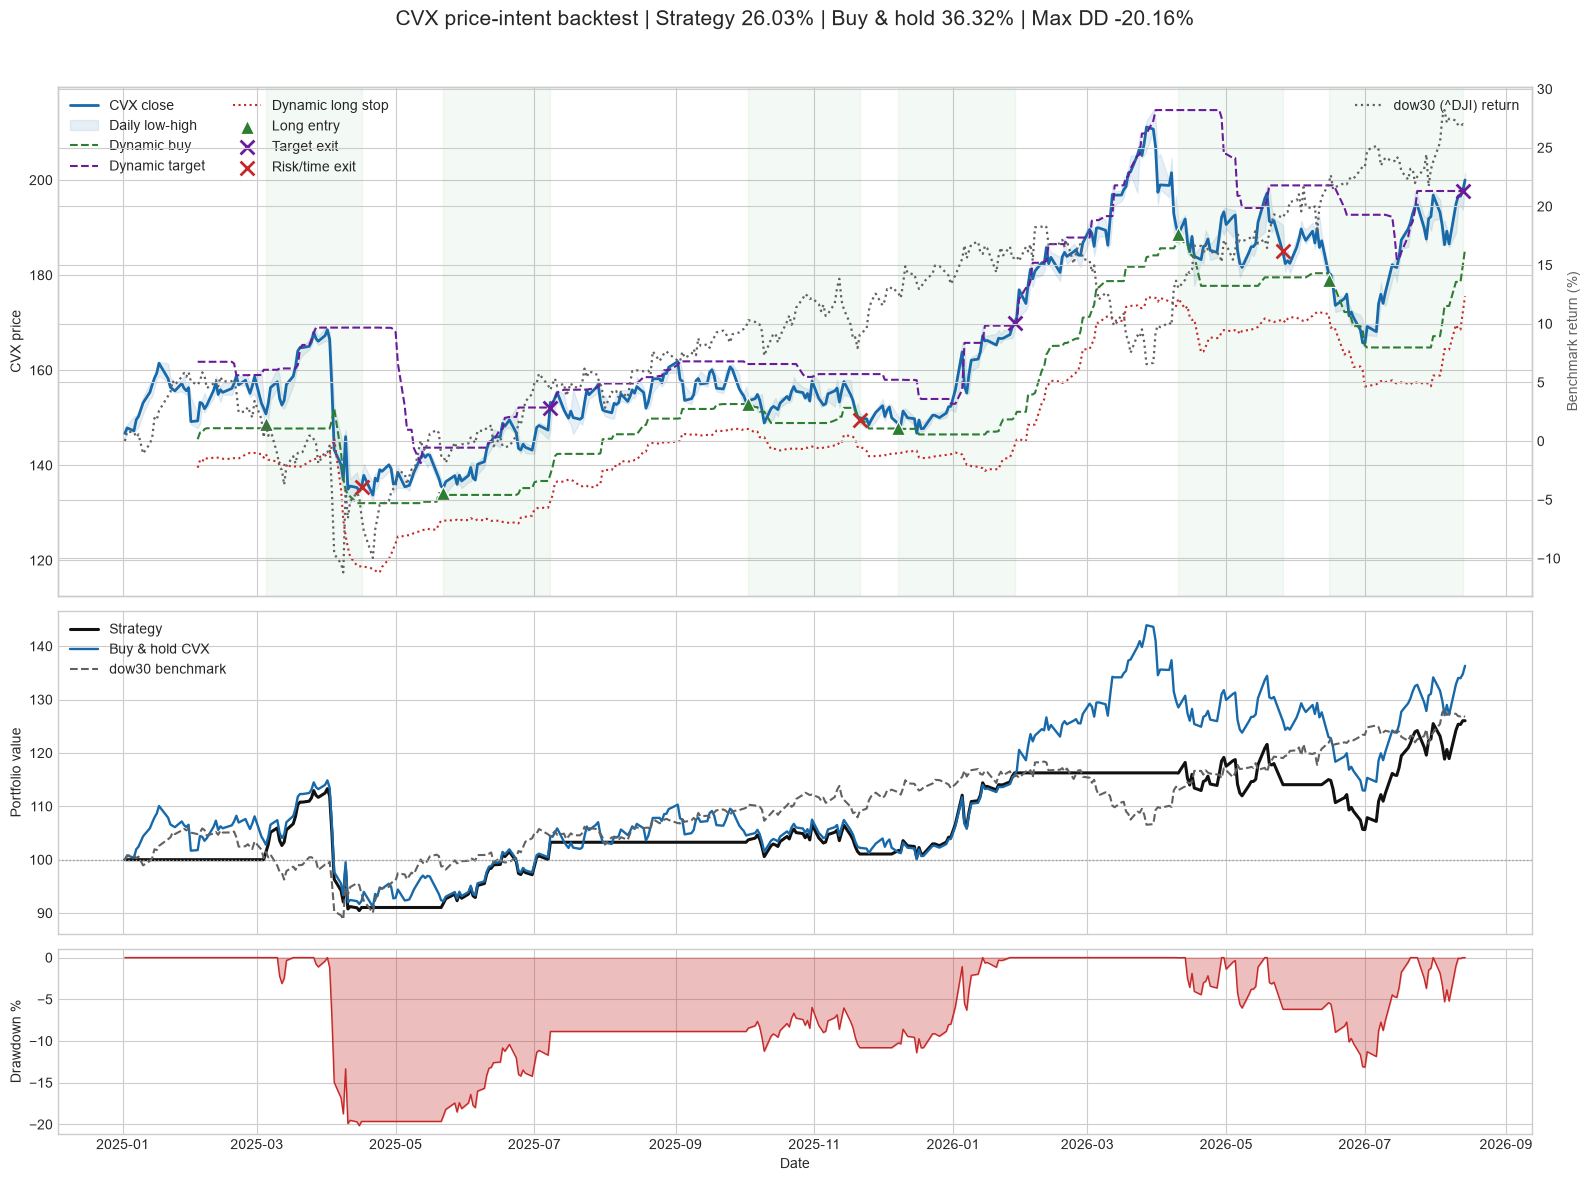

In [6]:
figures_by_ticker = {}
chart_files_by_ticker = {}
for current_ticker, backtest in backtests_by_ticker.items():
    market_data = market_data_by_ticker[current_ticker]
    dynamic_levels = dynamic_levels_by_ticker[current_ticker]
    fig, chart_file = plot_backtest_results(
        backtest=backtest,
        benchmark_history=market_data["benchmark_history"],
        ticker=current_ticker,
        index_name=index_name,
        benchmark_ticker=market_data["benchmark_ticker"],
        buy_price=dynamic_levels["buy_price"],
        sell_price=dynamic_levels["sell_price"],
        stop_loss=dynamic_levels["stop_loss"],
        initial_capital=initial_capital,
        chart_output_dir="output" if save_chart else None,
    )
    figures_by_ticker[current_ticker] = fig
    chart_files_by_ticker[current_ticker] = chart_file
    if chart_file is not None:
        print(f"Saved {current_ticker} chart to {chart_file.resolve()}")
    plt.show()

## Block 6: Simulated trade execution details

One row per simulated trade across every ticker, including the filled entry and exit, quantity, notional, fees, entry-time target and risk levels, holding period, and realized result. These are historical backtest fills for research—not live orders or a recommendation to trade.

In [7]:
trade_detail_frames = [
    prepare_trade_details(backtest, ticker=current_ticker)
    for current_ticker, backtest in backtests_by_ticker.items()
]
trade_details = pd.concat(trade_detail_frames, ignore_index=True)

if trade_details.empty:
    display(pd.DataFrame({"message": ["No simulated trade entries were executed."]}))
else:
    display(trade_details.sort_values(["entry_date", "ticker"]))

if export_results:
    for current_ticker, exported_files in exported_files_by_ticker.items():
        print(
            f"{current_ticker} trade-detail CSV: "
            f"{exported_files['trade_details'].resolve()}"
        )

,trade_number,ticker,side,status,buy_date,buy_price,sell_date,sell_price,entry_action,entry_date,...,exit_action,exit_date,exit_price,exit_notional,exit_commission,cash_after_exit,exit_reason,holding_sessions,realized_pnl,return_pct
0,1,CVX,LONG,CLOSED,2025-03-05,148.72,2025-04-16,135.40,BUY,2025-03-05,...,SELL,2025-04-16,135.40,91.04,0.00,91.04,TRAILING_STOP,30,-8.96,-8.96
1,2,CVX,LONG,CLOSED,2025-05-22,134.14,2025-07-08,152.15,BUY,2025-05-22,...,SELL,2025-07-08,152.15,103.27,0.00,103.27,TARGET,30,12.22,13.43
2,3,CVX,LONG,CLOSED,2025-10-03,152.88,2025-11-21,149.62,BUY,2025-10-03,...,SELL,2025-11-21,149.62,101.06,0.00,101.06,TRAILING_STOP,35,-2.20,-2.13
3,4,CVX,LONG,CLOSED,2025-12-08,147.74,2026-01-28,169.96,BUY,2025-12-08,...,SELL,2026-01-28,169.96,116.26,0.00,116.26,TARGET,34,15.20,15.04
4,5,CVX,LONG,CLOSED,2026-04-10,188.60,2026-05-26,185.02,BUY,2026-04-10,...,SELL,2026-05-26,185.02,114.05,0.00,114.05,TRAILING_STOP,31,-2.21,-1.90
5,6,CVX,LONG,CLOSED,2026-06-15,178.90,2026-08-13,197.69,BUY,2026-06-15,...,SELL,2026-08-13,197.69,126.03,0.00,126.03,TARGET,41,11.98,10.50
